特征名称： ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
目标类别： ['setosa' 'versicolor' 'virginica']
数据集大小： (150, 4)


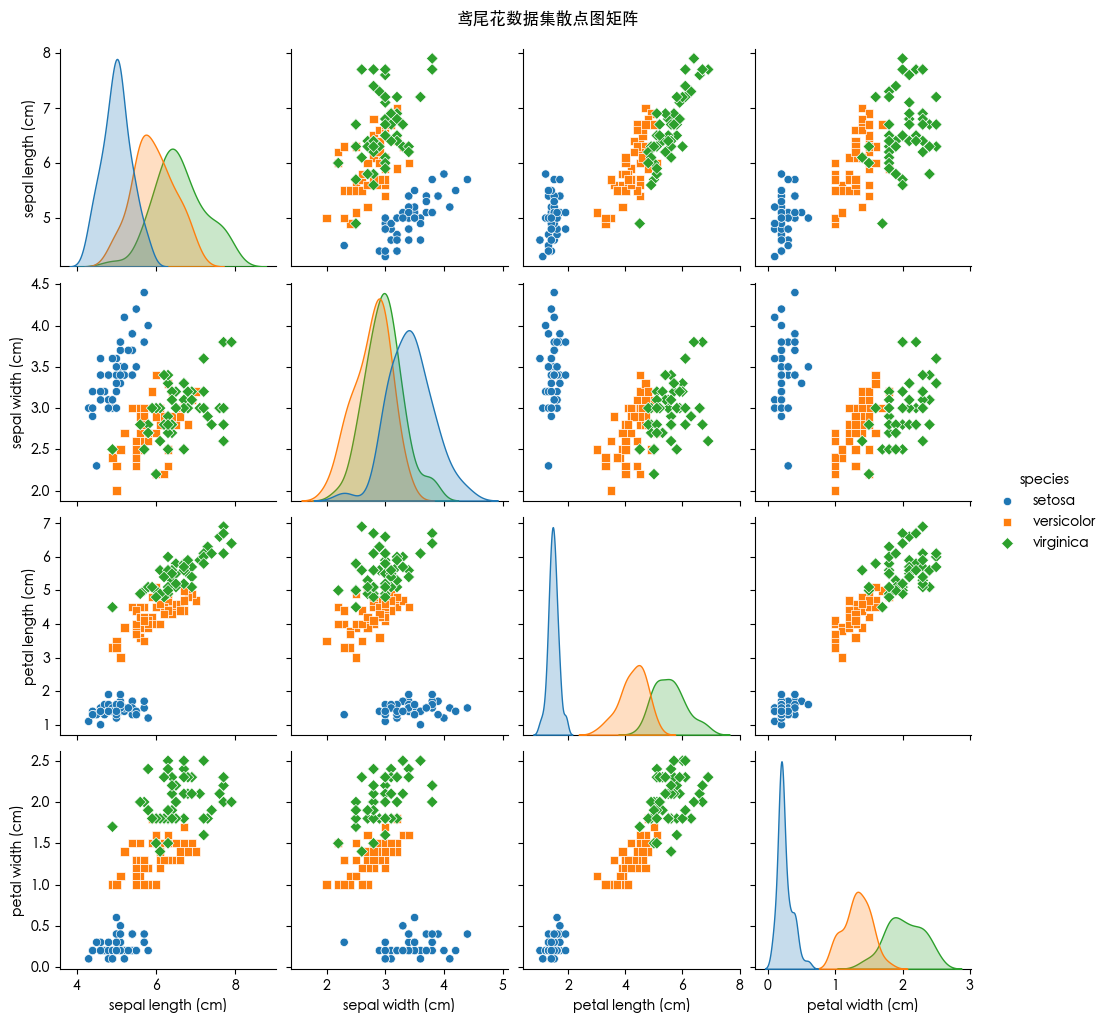


训练集特征均值： [ 2.38327876e-15 -1.12145742e-15 -1.37456184e-16 -6.97854473e-17]

训练集特征标准差： [1. 1. 1. 1.]
模型准确率：91.11%

混淆矩阵：
 [[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]

分类报告：
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from matplotlib import rcParams

# 配置 matplotlib 使用中文字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 加载鸢尾花数据集
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print("特征名称：", feature_names)
print("目标类别：", target_names)
print("数据集大小：", X.shape)

# 可视化数据分布
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
sns.pairplot(df, hue='species', markers=["o", "s", "D"])
plt.suptitle("鸢尾花数据集散点图矩阵", y=1.02)
plt.show()

# 切分数据集为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 特征标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n训练集特征均值：", X_train.mean(axis=0))
print("\n训练集特征标准差：", X_train.std(axis=0))
# 创建KNN模型，选择K=3
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

# 进行预测
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率：{accuracy * 100:.2f}%")

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)

# 分类报告
class_report = classification_report(y_test, y_pred, target_names=target_names)

print("\n混淆矩阵：\n", conf_matrix)
print("\n分类报告：\n", class_report)

### 模型性能总结
1. **训练集特征均值**：
   ```
   [ 2.38327876e-15 -1.12145742e-15 -1.37456184e-16 -6.97854473e-17]
   ```
   这些值非常接近于0，说明特征已经被标准化，均值接近0。

2. **训练集特征标准差**：
   ```
   [1. 1. 1. 1.]
   ```
   标准差为1，说明特征已经被标准化，每个特征的标准差都是1。

3. **模型准确率**：
   ```
   91.11%
   ```
   模型在测试集上的准确率为91.11%，表现良好。

4. **混淆矩阵**：
   ```
   [[15  0  0]
    [ 0 15  0]
    [ 0  4 11]]
   ```
   - 第一行：15个 setosa 样本全部被正确分类。
   - 第二行：15个 versicolor 样本全部被正确分类。
   - 第三行：15个 virginica 样本中有 4 个被错误分类为 versicolor ，11个被正确分类。

5. **分类报告**：
   ```
                   precision    recall  f1-score   support
    
          setosa       1.00      1.00      1.00        15
      versicolor       0.79      1.00      0.88        15
       virginica       1.00      0.73      0.85        15
    
        accuracy                           0.91        45
       macro avg       0.93      0.91      0.91        45
    weighted avg       0.93      0.91      0.91        45
   ```

   - **setosa**：精确率和召回率均为1.00，说明所有setosa样本都被正确分类。
   - **versicolor**：精确率为0.79，召回率为1.00，说明所有versicolor样本都被正确分类，但有部分其他类别的样本被错误分类为versicolor。
   - **virginica**：精确率为1.00，召回率为0.73，说明部分virginica样本被错误分类为其他类别。

### 后续工作

1. **调整K值**：尝试不同的K值，找到最优的K值。可以通过交叉验证来选择最佳的K值。
2. **特征选择**：检查哪些特征对分类贡献最大，是否可以剔除一些特征。
3. **数据可视化**：进一步可视化数据，看看是否有明显的聚类或分离趋势，帮助理解模型的分类行为。